# Text Data Preparation, Representation, and Unsupervised Learning

## 1. Text Data Preparation

This section focuses on loading the dataset and performing essential text preprocessing steps to clean and standardize the textual data for further analysis.

In [2]:
%pip install nltk

  Using cached nltk-3.10.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
  Using cached click-8.5.0-py3-none-any.whl.metadata (2.6 kB)
Using cached nltk-3.10.3-py3-none-any.whl (1.8 MB)
Using cached click-8.5.0-py3-none-any.whl (125 kB)
Using cached defusedxml-0.7.1-py2.py3-none-any.whl (25 kB)

   ---------------------------------------- 0/5 [tqdm]
   -------- ------------------------------- 1/5 [regex]
   ---------------- ----------------------- 2/5 [defusedxml]
   ------------------------ --------------- 3/5 [click]
   -------------------------------- ------- 4/5 [nltk]
   -------------------------------- ------- 4/5 [nltk]
   -------------------------------- ------- 4/5 [nltk]
   -------------------------------- ------- 4/5 [nltk]
   -------------------------------- ------- 4/5 [nltk]
   -------------------------------- ------- 4/5 [nltk]
   -------------------------------- ------- 4/5 [nltk]
   ----------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import nltk
import string
from nltk.corpus import stopwords, reuters
from nltk.tokenize import word_tokenize
# from sklearn.datasets import fetch_20newsgroups # No longer needed
# from tenacity import retry, wait_fixed, stop_after_attempt, Retrying # No longer needed for Reuters
import os

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('reuters') # Download the Reuters corpus

# Prepare Reuters dataset
# The Reuters corpus has a fileid for each document and categories for each fileid
doc_ids = reuters.fileids()
data = [reuters.raw(file_id) for file_id in doc_ids]

# Get categories for each document, flatten the list, and remove duplicates for target_names
all_categories = []
labels_map = {}
current_label_id = 0

labels = []
for file_id in doc_ids:
    doc_categories = reuters.categories(file_id)
    if doc_categories:
        # For simplicity, assign the first category as the label for this document
        # In a real scenario, you might handle multi-label documents differently
        category = doc_categories[0]
        if category not in labels_map:
            labels_map[category] = current_label_id
            current_label_id += 1
        labels.append(labels_map[category])
    else:
        labels.append(-1) # Documents with no categories

# Filter out documents without assigned categories (label -1)
filtered_data = []
filtered_labels = []
for i, doc_label in enumerate(labels):
    if doc_label != -1:
        filtered_data.append(data[i])
        filtered_labels.append(doc_label)

data = filtered_data
labels = filtered_labels

# Create target_names from the labels_map
target_names = [name for name, id in sorted(labels_map.items(), key=lambda item: item[1])]

print(f"Number of documents: {len(data)}")
print(f"Number of categories: {len(target_names)}")
print("Example document (first 200 chars):\n")
print(data[0][:200])
print("Example label and category:\n")
print(f"Label for first document: {labels[0]} ({target_names[labels[0]]})")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package reuters to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...


Number of documents: 10788
Number of categories: 79
Example document (first 200 chars):

ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RIFT
  Mounting trade friction between the
  U.S. And Japan has raised fears among many of Asia's exporting
  nations that the row could inflict far-reachin
Example label and category:

Label for first document: 0 (trade)


### Basic Text Preprocessing

I'll perform the following steps:
1.  **Tokenization**: Breaking down text into individual words or tokens.
2.  **Removing Stopwords**: Eliminating common words (e.g., 'the', 'is', 'a') that do not carry much meaning.
3.  **Removing Punctuation**: Removing punctuation marks.

In [4]:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Tokenization
    tokens = word_tokenize(text)
    # Remove stopwords and punctuation
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word.isalnum() and word not in stop_words]
    return ' '.join(tokens)

# Apply preprocessing to all documents
processed_data = [preprocess_text(doc) for doc in data]

print("Original document (first 200 chars):")
print(data[0][:200])
print("\nProcessed document (first 200 chars):")
print(processed_data[0][:200])

Original document (first 200 chars):
ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RIFT
  Mounting trade friction between the
  U.S. And Japan has raised fears among many of Asia's exporting
  nations that the row could inflict far-reachin

Processed document (first 200 chars):
asian exporters fear damage rift mounting trade friction japan raised fears among many asia exporting nations row could inflict economic damage businessmen officials said told reuter correspondents as


## 2. Text Representation

This section explores different methods to convert raw text into numerical features that can be used by machine learning algorithms. I would cover Bag of Words and TF-IDF.

### Bag of Words (BoW)

Bag of Words represents text as an unordered collection of words, keeping track of their frequencies. It's a simple yet effective method for feature extraction.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

# Create a CountVectorizer object
vectorizer_bow = CountVectorizer()

# Fit and transform the processed data to create the BoW matrix
X_bow = vectorizer_bow.fit_transform(processed_data)

print(f"Shape of Bag of Words matrix: {X_bow.shape}")
print("First 5 feature names (words):\n", vectorizer_bow.get_feature_names_out()[:5])
print("\nSample BoW vector for the first document (non-zero entries):\n", X_bow[0])

Shape of Bag of Words matrix: (10788, 29011)
First 5 feature names (words):
 ['000' '0100' '0230' '0300' '0400']

Sample BoW vector for the first document (non-zero entries):
 <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 280 stored elements and shape (1, 29011)>
  Coords	Values
  (0, 2745)	2
  (0, 10007)	3
  (0, 10288)	1
  (0, 7335)	2
  (0, 22418)	1
  (0, 17332)	1
  (0, 26605)	15
  (0, 11081)	1
  (0, 14273)	12
  (0, 21102)	1
  (0, 10292)	1
  (0, 2202)	2
  (0, 16137)	1
  (0, 2744)	1
  (0, 10008)	1
  (0, 17626)	1
  (0, 22690)	1
  (0, 6852)	1
  (0, 13615)	1
  (0, 9000)	2
  (0, 4636)	4
  (0, 18414)	2
  (0, 22872)	16
  (0, 26455)	1
  (0, 22269)	1
  :	:
  (0, 9262)	1
  (0, 16491)	1
  (0, 24962)	1
  (0, 7916)	1
  (0, 20432)	1
  (0, 28861)	1
  (0, 17553)	1
  (0, 3107)	1
  (0, 10590)	1
  (0, 21615)	1
  (0, 20551)	1
  (0, 7851)	2
  (0, 21994)	1
  (0, 16745)	1
  (0, 24187)	1
  (0, 16029)	1
  (0, 14951)	1
  (0, 13939)	1
  (0, 17019)	1
  (0, 8798)	1
  (0, 16544)	1
  (0, 28171)	1
  (0

### TF-IDF (Term Frequency-Inverse Document Frequency)

TF-IDF is a numerical statistic that reflects how important a word is to a document in a collection or corpus. It is often used as a weighting factor in information retrieval and text mining.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create a TfidfVectorizer object
vectorizer_tfidf = TfidfVectorizer()

# Fit and transform the processed data to create the TF-IDF matrix
X_tfidf = vectorizer_tfidf.fit_transform(processed_data)

print(f"Shape of TF-IDF matrix: {X_tfidf.shape}")
print("First 5 feature names (words):\n", vectorizer_tfidf.get_feature_names_out()[:5])
print("\nSample TF-IDF vector for the first document (non-zero entries):\n", X_tfidf[0])

Shape of TF-IDF matrix: (10788, 29011)
First 5 feature names (words):
 ['000' '0100' '0230' '0300' '0400']

Sample TF-IDF vector for the first document (non-zero entries):
 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 280 stored elements and shape (1, 29011)>
  Coords	Values
  (0, 2745)	0.08333618637093887
  (0, 10007)	0.10112077140042929
  (0, 10288)	0.04180015688765432
  (0, 7335)	0.07326789787457416
  (0, 22418)	0.05817860686263909
  (0, 17332)	0.04674420824186361
  (0, 26605)	0.32193243283389783
  (0, 11081)	0.045942765331391085
  (0, 14273)	0.29785479552972044
  (0, 21102)	0.030043230661828565
  (0, 10292)	0.039562655600079606
  (0, 2202)	0.061582246448624325
  (0, 16137)	0.030109821365919973
  (0, 2744)	0.04128719335812551
  (0, 10008)	0.04026192495624024
  (0, 17626)	0.030199677501341612
  (0, 22690)	0.040476269762999645
  (0, 6852)	0.02237250870322934
  (0, 13615)	0.06270966210118031
  (0, 9000)	0.05135988325306752
  (0, 4636)	0.1712313169334508
  (0, 18414)	0.

### Basic Word Embeddings (Conceptual Introduction)

Word embeddings are dense vector representations of words that capture semantic relationships. Words with similar meanings are mapped to nearby points in the vector space. While training sophisticated embeddings is computationally intensive, we can illustrate the concept with a simple pre-trained model or by generating random embeddings for a small vocabulary for demonstration purposes.

For a full-fledged application, libraries like `Gensim` (for Word2Vec, GloVe, FastText) or pre-trained models from `Hugging Face Transformers` would be used. Below is a conceptual illustration. If `gensim` were installed and pre-trained vectors available, you would load them like this:

```python
# Example of loading a pre-trained Word2Vec model (conceptual)
# import gensim.downloader as api
# model = api.load('word2vec-google-news-300') # This is a very large model
# print(model['computer'])
```

For a simpler, illustrative example without heavy downloads, we can generate random vectors for a few words.

In [7]:
import numpy as np

# Get a small sample of words from our vocabulary
sample_words = vectorizer_bow.get_feature_names_out()[100:110] # Take 10 words

# For illustration, let's create random 50-dimensional vectors for these words
# In a real scenario, these would be learned or loaded from a pre-trained model.
word_embedding_dim = 50
word_embeddings = {word: np.random.rand(word_embedding_dim) for word in sample_words}

print("Sample word embeddings (randomly generated for illustration):")
for word, embedding in list(word_embeddings.items())[:3]:
    print(f"{word}: {embedding[:5]}...") # Print first 5 dimensions for brevity

Sample word embeddings (randomly generated for illustration):
1400: [0.75436886 0.21121287 0.10809706 0.32377791 0.013394  ]...
141: [0.62490409 0.34549736 0.18318862 0.20578364 0.02355001]...
142: [0.44018512 0.94663722 0.88347713 0.89977627 0.50790113]...


## 3. Unsupervised Learning Application

In this section, we'll apply clustering algorithms to discover natural groupings within our text data. We will use K-Means, a popular partitioning algorithm, and analyze the resulting clusters.

### K-Means Clustering

K-Means aims to partition `n` observations into `k` clusters in which each observation belongs to the cluster with the nearest mean (cluster centers or cluster centroid). We will apply K-Means to our TF-IDF features.

Number of clusters (k): 79
First 10 cluster assignments: [35 71  7 25 32 66 67  8 63 26]

Silhouette Score: 0.031


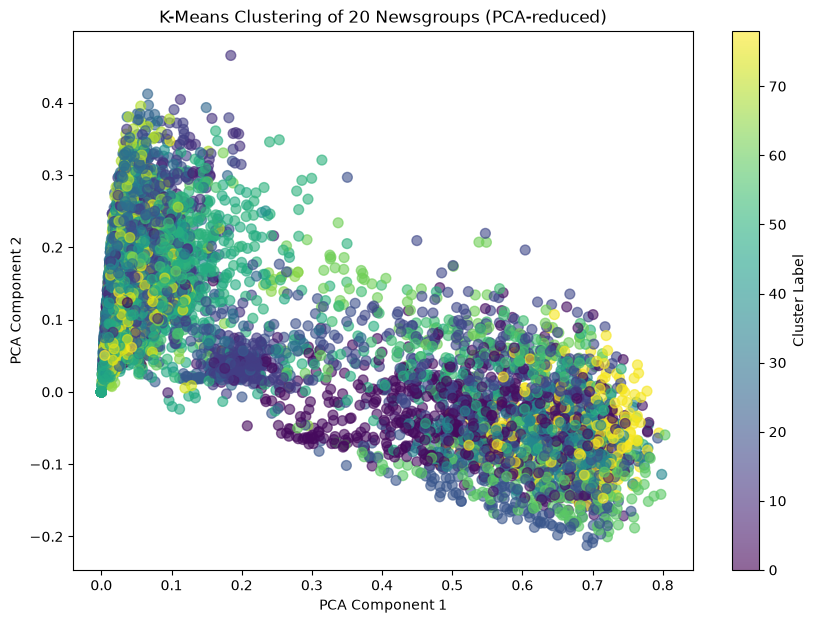

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD

# Determine optimal number of clusters (e.g., using target_names for guidance, or Elbow Method/Silhouette Score)
k = len(target_names) # A good starting point is the number of actual categories

# Apply K-Means clustering
kmeans_model = KMeans(n_clusters=k, init='k-means++', max_iter=100, random_state=42, n_init=10)
kmeans_model.fit(X_tfidf)

cluster_labels = kmeans_model.labels_
cluster_centers = kmeans_model.cluster_centers_

print(f"Number of clusters (k): {k}")
print(f"First 10 cluster assignments: {cluster_labels[:10]}")

# Evaluate clustering using Silhouette Score
# The Silhouette Score is defined for more than 1 cluster
if X_tfidf.shape[0] > 1 and k > 1:
    sample_size = min(2000, X_tfidf.shape[0])
    silhouette_avg = silhouette_score(
        X_tfidf,
        cluster_labels,
        sample_size=sample_size,
        random_state=42
    )
    print(f"\nSilhouette Score: {silhouette_avg:.3f}")
else:
    print("\nCannot calculate Silhouette Score with 1 or fewer samples, or 1 cluster.")

# Dimensionality Reduction for Visualization (PCA)
# We'll reduce the TF-IDF features to 2 components for plotting
pca = PCA(n_components=2, random_state=42)
# Sparse-safe dimensionality reduction; avoids converting 29,011 features to dense
svd = TruncatedSVD(n_components=2, random_state=42)
X_pca = svd.fit_transform(X_tfidf)

# Plot the clusters
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=50, alpha=0.6)
plt.title('K-Means Clustering of 20 Newsgroups (PCA-reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

### Cluster Analysis and Interpretation

To understand the topics or themes within each cluster, we can examine the most representative terms (words with the highest TF-IDF scores) for each cluster's centroid.

In [11]:
print("Top terms per cluster:")
order_centroids = cluster_centers.argsort()[:, ::-1]
terms = vectorizer_tfidf.get_feature_names_out()

for i in range(k):
    print(f"Cluster {i}:")
    top_terms = [terms[ind] for ind in order_centroids[i, :10]] # Get top 10 terms
    print(f"  {', '.join(top_terms)}")

Top terms per cluster:
Cluster 0:
  becor, corning, shareholders, merger, vote, meeting, vernitron, said, lt, hazleton
Cluster 1:
  copper, cents, price, lb, tons, magma, effective, immediately, cent, said
Cluster 2:
  vs, cts, net, 1st, qtr, shr, mln, lt, note, revs
Cluster 3:
  oper, vs, cts, net, loss, mln, dlrs, shr, excludes, profit
Cluster 4:
  days, pct, discount, rate, maturity, bills, rates, bill, top, tender
Cluster 5:
  profit, vs, cts, loss, net, mln, shr, revs, qtr, nine
Cluster 6:
  qtrly, cts, div, payout, pay, record, april, sets, prior, vs
Cluster 7:
  gas, oil, natural, said, cubic, feet, barrels, mln, reserves, energy
Cluster 8:
  wheat, tonnes, said, export, usda, department, tender, agriculture, grain, soft
Cluster 9:
  sugar, tonnes, white, traders, ec, said, ecus, intervention, tender, rebate
Cluster 10:
  tax, oils, ec, soybean, would, fats, farm, said, loan, agriculture
Cluster 11:
  billion, dlrs, rose, fell, money, week, balances, treasury, mln, assets
Cluste

## 4. Model Evaluation and Prediction

This section demonstrates how to use the trained clustering model to predict cluster assignments for new, unseen documents and validates its effectiveness.

### Predicting Cluster Assignments for New Documents

I'll simulate new documents by taking a few examples from our existing dataset that were not used during clustering (or generate entirely new text) and predict their cluster.

In [12]:
from sklearn.model_selection import train_test_split

# Split data to simulate 'new' unseen documents
# For simplicity, we'll use a small portion of existing data as 'new'
# In a real scenario, these would be genuinely new texts.
X_train, X_test, y_train, y_test, processed_data_train, processed_data_test = \
    train_test_split(X_tfidf, labels, processed_data, test_size=0.2, random_state=42)

# Re-train KMeans on the 'training' part of the TF-IDF data (optional, but good practice)
kmeans_model_retrain = KMeans(n_clusters=k, init='k-means++', max_iter=100, random_state=42, n_init=10)
kmeans_model_retrain.fit(X_train)

# Select a few 'new' documents to predict
num_new_docs = 3
sample_indices = np.random.choice(range(X_test.shape[0]), num_new_docs, replace=False)

print("Predicting cluster assignments for new documents:")
for i, idx in enumerate(sample_indices):
    new_doc_tfidf = X_test[idx]
    predicted_cluster = kmeans_model_retrain.predict(new_doc_tfidf)[0]
    original_category = target_names[y_test[idx]]
    print(f"\nDocument {i+1} (Original Category: {original_category}):")
    print(f"  Processed Text: {processed_data_test[idx][:200]}...")
    print(f"  Predicted Cluster: {predicted_cluster}")
    print(f"  Top terms in Predicted Cluster {predicted_cluster}: {', '.join([terms[ind] for ind in order_centroids[predicted_cluster, :5]])}")

Predicting cluster assignments for new documents:

Document 1 (Original Category: cocoa):
  Processed Text: corrected coast confirms presence talks senior ivory coast agriculture ministry official confirmed country backing new international cocoa pact said ivorian delegates would present talks buffer stock ...
  Predicted Cluster: 14
  Top terms in Predicted Cluster 14: cts, qtly, div, record, pay

Document 2 (Original Category: acq):
  Processed Text: waste management amends chemlawn offer raising 35 dlrs share 33 dlrs waste management amends chemlawn offer raising 35 dlrs share 33 dlrs...
  Predicted Cluster: 15
  Top terms in Predicted Cluster 15: billion, surplus, deficit, february, trade

Document 3 (Original Category: acq):
  Processed Text: german veba placement said likely early next week placement german federal government pct stake utility veba ag lt would probably take place early next week banking sources said share dealers said spe...
  Predicted Cluster: 36
  Top terms in

## 3. Unsupervised Learning Application

In this section, we'll apply clustering algorithms to discover natural groupings within our text data. We will use K-Means, a popular partitioning algorithm, and analyze the resulting clusters.

### K-Means Clustering

K-Means aims to partition `n` observations into `k` clusters in which each observation belongs to the cluster with the nearest mean (cluster centers or cluster centroid). We will apply K-Means to our TF-IDF features.

Number of clusters (k): 79
First 10 cluster assignments: [35 71  7 25 32 66 67  8 63 26]
Number of clusters (k): 79
First 10 cluster assignments: [35 71  7 25 32 66 67  8 63 26]

Silhouette Score: 0.031


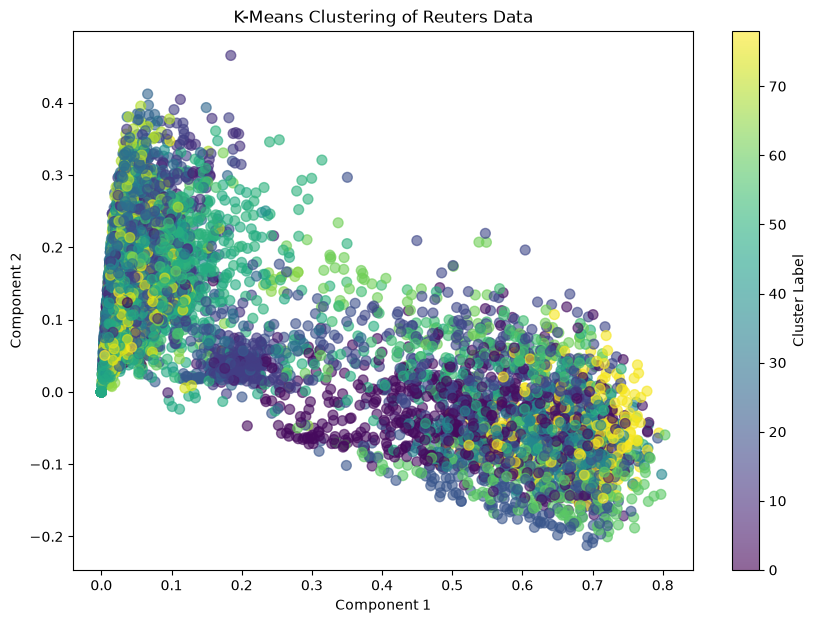

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

# Determine optimal number of clusters (e.g., using target_names for guidance, or Elbow Method/Silhouette Score)
k = len(target_names) # A good starting point is the number of actual categories

# Apply K-Means clustering
kmeans_model = KMeans(n_clusters=k, init='k-means++', max_iter=100, random_state=42, n_init=10)
kmeans_model.fit(X_tfidf)

cluster_labels = kmeans_model.labels_
cluster_centers = kmeans_model.cluster_centers_

print(f"Number of clusters (k): {k}")
print(f"First 10 cluster assignments: {cluster_labels[:10]}")

# Evaluate clustering using Silhouette Score
# The Silhouette Score is defined for more than 1 cluster
if X_tfidf.shape[0] > 1 and k > 1:
    sample_size = min(2000, X_tfidf.shape[0])
    silhouette_avg = silhouette_score(
        X_tfidf,
        cluster_labels,
        sample_size=sample_size,
        random_state=42
    )
svd = TruncatedSVD(n_components=2, random_state=42)
X_pca = svd.fit_transform(X_tfidf)
    

k = len(target_names)

kmeans_model = KMeans(
        n_clusters=k,
        init="k-means++",
        max_iter=100,
        random_state=42,
        n_init=10
    )
kmeans_model.fit(X_tfidf)

cluster_labels = kmeans_model.labels_
cluster_centers = kmeans_model.cluster_centers_

print(f"Number of clusters (k): {k}")
print(f"First 10 cluster assignments: {cluster_labels[:10]}")

if X_tfidf.shape[0] > 1 and k > 1:
    sample_size = min(2000, X_tfidf.shape[0])
    silhouette_avg = silhouette_score(
        X_tfidf,
        cluster_labels,
        sample_size=sample_size,
        random_state=42
    )
    print(f"\nSilhouette Score: {silhouette_avg:.3f}")
else:
    print("\nCannot calculate Silhouette Score.")

# X_pca was already computed above using TruncatedSVD.
plt.figure(figsize=(10, 7))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap="viridis",
    s=50,
    alpha=0.6
)
plt.title("K-Means Clustering of Reuters Data")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster Label")
plt.show()

### Cluster Analysis and Interpretation

To understand the topics or themes within each cluster, we can examine the most representative terms (words with the highest TF-IDF scores) for each cluster's centroid.

In [15]:
print("Top terms per cluster:")
order_centroids = cluster_centers.argsort()[:, ::-1]
terms = vectorizer_tfidf.get_feature_names_out()

for i in range(k):
    print(f"Cluster {i}:")
    top_terms = [terms[ind] for ind in order_centroids[i, :10]] # Get top 10 terms
    print(f"  {', '.join(top_terms)}")

Top terms per cluster:
Cluster 0:
  becor, corning, shareholders, merger, vote, meeting, vernitron, said, lt, hazleton
Cluster 1:
  copper, cents, price, lb, tons, magma, effective, immediately, cent, said
Cluster 2:
  vs, cts, net, 1st, qtr, shr, mln, lt, note, revs
Cluster 3:
  oper, vs, cts, net, loss, mln, dlrs, shr, excludes, profit
Cluster 4:
  days, pct, discount, rate, maturity, bills, rates, bill, top, tender
Cluster 5:
  profit, vs, cts, loss, net, mln, shr, revs, qtr, nine
Cluster 6:
  qtrly, cts, div, payout, pay, record, april, sets, prior, vs
Cluster 7:
  gas, oil, natural, said, cubic, feet, barrels, mln, reserves, energy
Cluster 8:
  wheat, tonnes, said, export, usda, department, tender, agriculture, grain, soft
Cluster 9:
  sugar, tonnes, white, traders, ec, said, ecus, intervention, tender, rebate
Cluster 10:
  tax, oils, ec, soybean, would, fats, farm, said, loan, agriculture
Cluster 11:
  billion, dlrs, rose, fell, money, week, balances, treasury, mln, assets
Cluste

## 4. Model Evaluation and Prediction

This section demonstrates how to use the trained clustering model to predict cluster assignments for new, unseen documents and validates its effectiveness.

### Predicting Cluster Assignments for New Documents

We'll simulate new documents by taking a few examples from our existing dataset that were not used during clustering (or generate entirely new text) and predict their cluster.

In [16]:
from sklearn.model_selection import train_test_split

# Split data to simulate 'new' unseen documents
# For simplicity, we'll use a small portion of existing data as 'new'
# In a real scenario, these would be genuinely new texts.
X_train, X_test, y_train, y_test, processed_data_train, processed_data_test = \
    train_test_split(X_tfidf, labels, processed_data, test_size=0.2, random_state=42)

# Re-train KMeans on the 'training' part of the TF-IDF data (optional, but good practice)
kmeans_model_retrain = KMeans(n_clusters=k, init='k-means++', max_iter=100, random_state=42, n_init=10)
kmeans_model_retrain.fit(X_train)

# Select a few 'new' documents to predict
num_new_docs = 3
sample_indices = np.random.choice(range(X_test.shape[0]), num_new_docs, replace=False)

print("Predicting cluster assignments for new documents:")
for i, idx in enumerate(sample_indices):
    new_doc_tfidf = X_test[idx]
    predicted_cluster = kmeans_model_retrain.predict(new_doc_tfidf)[0]
    original_category = target_names[y_test[idx]]
    print(f"\nDocument {i+1} (Original Category: {original_category}):")
    print(f"  Processed Text: {processed_data_test[idx][:200]}...")
    print(f"  Predicted Cluster: {predicted_cluster}")
    print(f"  Top terms in Predicted Cluster {predicted_cluster}: {', '.join([terms[ind] for ind in order_centroids[predicted_cluster, :5]])}")

Predicting cluster assignments for new documents:

Document 1 (Original Category: acq):
  Processed Text: dennison manufacturing lt dsn sell paper unit dennison manufacturing co said signed letter intent sell dunn paper co subsidiary james river corp lt jr undisclosed amount cash resulting first quarter c...
  Predicted Cluster: 63
  Top terms in Predicted Cluster 63: gold, mine, ounces, said, ounce

Document 2 (Original Category: interest):
  Processed Text: morgan lt jpm increases prime rate morgan co inc said raising prime lending rate pct pct effective today major banks posting pct rate citibank first announce increase tuesday...
  Predicted Cluster: 35
  Top terms in Predicted Cluster 35: trade, japan, japanese, said, would

Document 3 (Original Category: cpi):
  Processed Text: philippine inflation predicted rise philippine 1987 inflation rate rise pct pct 1986 government implements employers association recommendation 10 pct increase 54 peso minimum daily wage month economi...
 